In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("session22.db")
cursor = conn.cursor()

cursor.executescript("""
DROP TABLE IF EXISTS restaurants;
DROP TABLE IF EXISTS movies;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS matches;
DROP TABLE IF EXISTS users;

CREATE TABLE restaurants (
    restaurant_id INTEGER PRIMARY KEY,
    name TEXT,
    cuisine TEXT,
    rating REAL
);

CREATE TABLE movies (
    movie_id INTEGER PRIMARY KEY,
    title TEXT,
    rating REAL
);

CREATE TABLE users (
    user_id INTEGER PRIMARY KEY,
    user_name TEXT
);

CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    user_id INTEGER,
    food_item TEXT,
    order_date TEXT
);

CREATE TABLE matches (
    match_id INTEGER PRIMARY KEY,
    team1 TEXT,
    team2 TEXT
);
""")

restaurants = [
    (1, "Spice Villa", "Indian", 4.5),
    (2, "Dragon Wok", "Chinese", 4.7),
    (3, "Southern Tadka", "South Indian", 4.3),
    (4, "Pizza Corner", "Italian", 4.1),
    (5, "Green Bowl", "Healthy", 3.9),
    (6, "Dosa House", "South Indian", 4.8)
]

movies = [
    (1, "Inception", 8.8),
    (2, "Interstellar", 8.7),
    (3, "The Dark Knight", 9.0),
    (4, "Parasite", 8.5),
    (5, "Dune", 8.0),
    (6, "Barbie", 7.0),
    (7, "Oppenheimer", 8.6),
    (8, "The Social Network", 7.8)
]

users = [(i, f"User {i}") for i in range(1, 11)]

food_items = (
    ["Biryani"] * 4 +
    ["Pizza"] * 3 +
    ["Burger"] * 2 +
    ["Pasta", "Dosa"]
)

orders = [
    (i, ((i - 1) % 10) + 1, food_items[(i - 1) % len(food_items)], f"2026-09-{((i - 1) % 30) + 1:02d}")
    for i in range(1, 121)
]

matches = [
    (1, "Mumbai Indians", "Chennai Super Kings"),
    (2, "Delhi Capitals", "Mumbai Indians"),
    (3, "Royal Challengers Bengaluru", "Kolkata Knight Riders"),
    (4, "Mumbai Indians", "Rajasthan Royals"),
    (5, "Chennai Super Kings", "Delhi Capitals"),
    (6, "Kolkata Knight Riders", "Mumbai Indians"),
    (7, "Rajasthan Royals", "Chennai Super Kings"),
    (8, "Delhi Capitals", "Royal Challengers Bengaluru"),
    (9, "Mumbai Indians", "Royal Challengers Bengaluru"),
    (10, "Chennai Super Kings", "Kolkata Knight Riders")
]

cursor.executemany("INSERT INTO restaurants VALUES (?, ?, ?, ?)", restaurants)
cursor.executemany("INSERT INTO movies VALUES (?, ?, ?)", movies)
cursor.executemany("INSERT INTO users VALUES (?, ?)", users)
cursor.executemany("INSERT INTO orders VALUES (?, ?, ?, ?)", orders)
cursor.executemany("INSERT INTO matches VALUES (?, ?, ?)", matches)

conn.commit()

print("Session 22 database is ready.")

Session 22 database is ready.


In [2]:
restaurants_df = pd.read_sql(
    "SELECT name, cuisine, rating FROM restaurants",
    conn
)

restaurants_df.head()

,name,cuisine,rating
0,Spice Villa,Indian,4.5
1,Dragon Wok,Chinese,4.7
2,Southern Tadka,South Indian,4.3
3,Pizza Corner,Italian,4.1
4,Green Bowl,Healthy,3.9


In [3]:
%pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [4]:
%load_ext sql
%sql sqlite:///session22.db

In [5]:
%sql SELECT title, rating FROM movies WHERE rating > 8 ORDER BY rating DESC;

 * sqlite:///session22.db
Done.


title,rating
The Dark Knight,9.0
Inception,8.8
Interstellar,8.7
Oppenheimer,8.6
Parasite,8.5


In [6]:
%pip install prettytable==3.10.2

Note: you may need to restart the kernel to use updated packages.


In [7]:
last_100_orders = pd.read_sql(
    """
    SELECT order_id, user_id, food_item, order_date
    FROM orders
    ORDER BY order_id DESC
    LIMIT 100
    """,
    conn
)

top_3_items = (
    last_100_orders.groupby("food_item")
    .size()
    .reset_index(name="order_count")
    .sort_values("order_count", ascending=False)
    .head(3)
)

top_3_items

,food_item,order_count
0,Biryani,36
4,Pizza,27
1,Burger,18


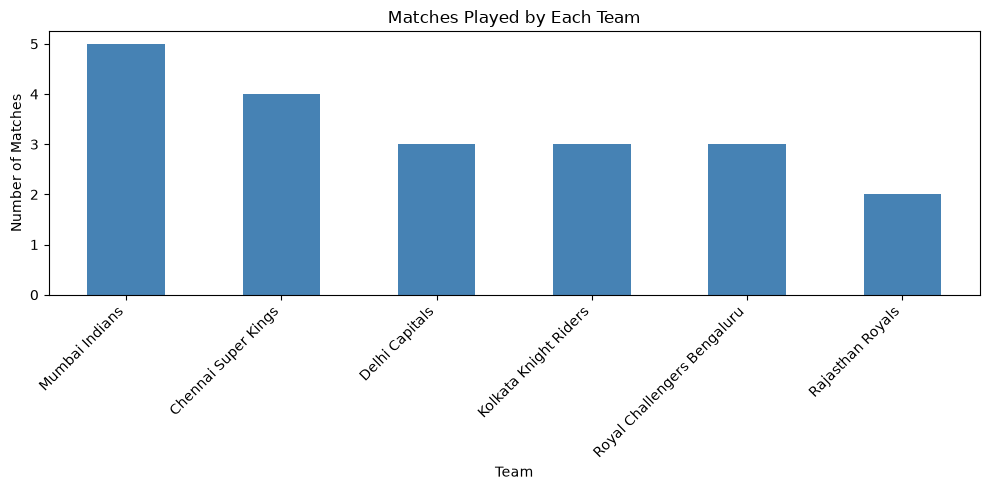

In [8]:
import matplotlib.pyplot as plt

matches_df = pd.read_sql(
    "SELECT team1, team2 FROM matches",
    conn
)

teams_df = pd.concat(
    [matches_df["team1"], matches_df["team2"]],
    ignore_index=True
).to_frame(name="team")

matches_per_team = (
    teams_df.groupby("team")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
matches_per_team.plot(kind="bar", color="steelblue")
plt.title("Matches Played by Each Team")
plt.xlabel("Team")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
frequent_users_df = pd.read_sql(
    """
    SELECT
        u.user_id,
        u.user_name,
        COUNT(o.order_id) AS total_orders
    FROM users AS u
    INNER JOIN orders AS o
        ON u.user_id = o.user_id
    GROUP BY
        u.user_id,
        u.user_name
    HAVING COUNT(o.order_id) > 5
    ORDER BY total_orders DESC
    """,
    conn
)

frequent_users_df

,user_id,user_name,total_orders
0,1,User 1,12
1,2,User 2,12
2,3,User 3,12
3,4,User 4,12
4,5,User 5,12
5,6,User 6,12
6,7,User 7,12
7,8,User 8,12
8,9,User 9,12
9,10,User 10,12
